<a href="https://colab.research.google.com/github/pushpakgaidhane294/NNDL_lab/blob/main/Practical9_NNDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# ============================================================
# CELL 1: Import Required Libraries
# ============================================================

!pip -q install tensorflow scikit-learn pandas matplotlib seaborn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

np.random.seed(42)
tf.random.set_seed(42)

print("Environment ready.")
print("TensorFlow version:", tf.__version__)

Environment ready.
TensorFlow version: 2.21.0


In [19]:
# ============================================================
# CELL 2: Load IMDB Dataset
# ============================================================

VOCAB_SIZE = 10000

print("Loading IMDB movie review dataset...")

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("\nDataset loaded successfully.")

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("First review:", X_train[0])
print("First label  :", y_train[0])

print("\nLabel meaning:")
print("0 = Negative")
print("1 = Positive")

Loading IMDB movie review dataset...

Dataset loaded successfully.
Training samples: 25000
Testing samples : 25000
First review: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88

Minimum review length: 11
Maximum review length: 2494
Average review length: 238.71364


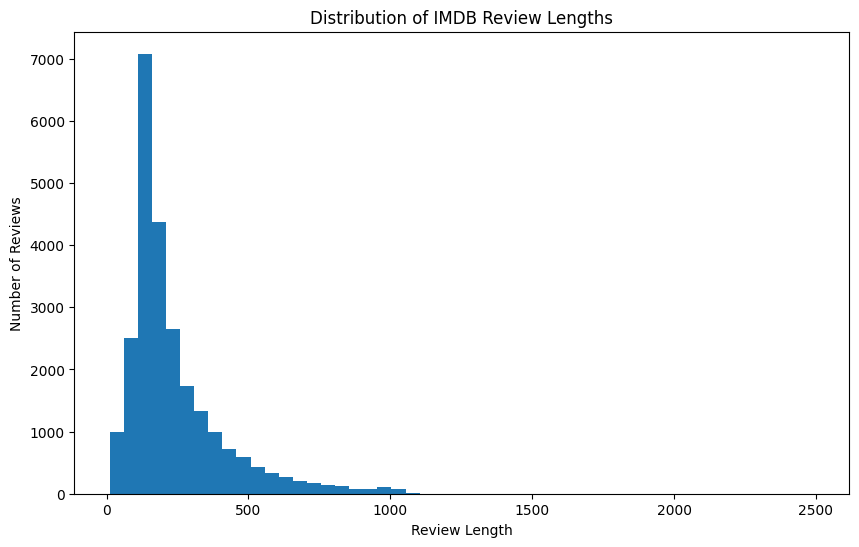

In [20]:
# ============================================================
# CELL 3: Check Review Lengths
# ============================================================

review_lengths = [len(review) for review in X_train]

print("Minimum review length:", min(review_lengths))
print("Maximum review length:", max(review_lengths))
print("Average review length:", np.mean(review_lengths))

plt.figure(figsize=(10, 6))

plt.hist(
    review_lengths,
    bins=50
)

plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.title("Distribution of IMDB Review Lengths")

plt.show()

In [21]:
# ============================================================
# CELL 4: Pad Sequences
# ============================================================

MAX_LENGTH = 300

X_train_padded = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("After padding:")

print("Training shape:", X_train_padded.shape)
print("Testing shape :", X_test_padded.shape)

After padding:
Training shape: (25000, 300)
Testing shape : (25000, 300)


In [22]:
# ============================================================
# CELL 5: Build Improved RNN Model
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam

VOCAB_SIZE = 20000
EMBEDDING_DIM = 128
MAX_LENGTH = 300

# Reload dataset with larger vocabulary
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

X_train_padded = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(
            64,
            return_sequences=False
        )
    ),

    Dropout(0.5),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])

model.compile(
    optimizer=Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# ============================================================
# CELL 6: Train Improved RNN
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

history = model.fit(
    X_train_padded,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.20,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

print("Training completed.")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.6497 - loss: 0.5918 - val_accuracy: 0.8324 - val_loss: 0.4118 - learning_rate: 5.0000e-04
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8794 - loss: 0.3054 - val_accuracy: 0.8720 - val_loss: 0.3150 - learning_rate: 5.0000e-04
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9329 - loss: 0.1942 - val_accuracy: 0.8208 - val_loss: 0.4066 - learning_rate: 5.0000e-04
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9603 - loss: 0.1212 - val_accuracy: 0.8830 - val_loss: 0.3853 - learning_rate: 2.5000e-04
Training completed.


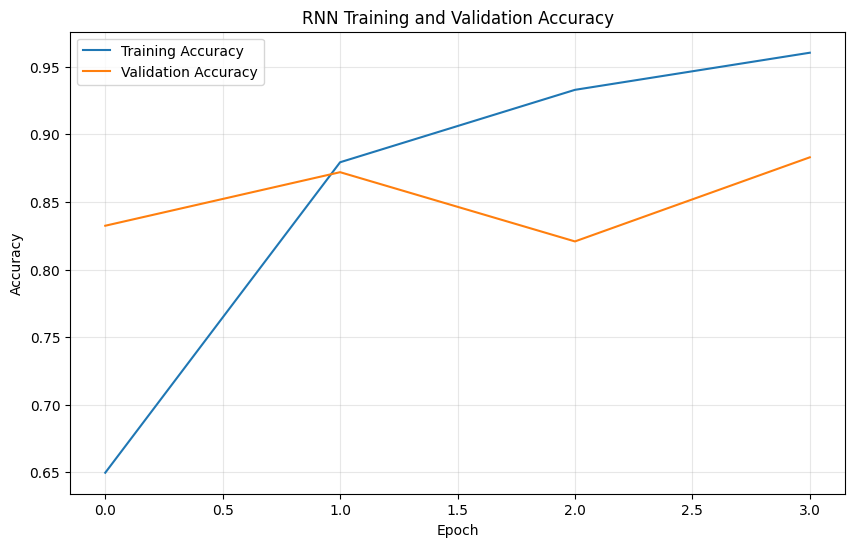

In [25]:
# ============================================================
# CELL 7: Plot Training Accuracy
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "RNN Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

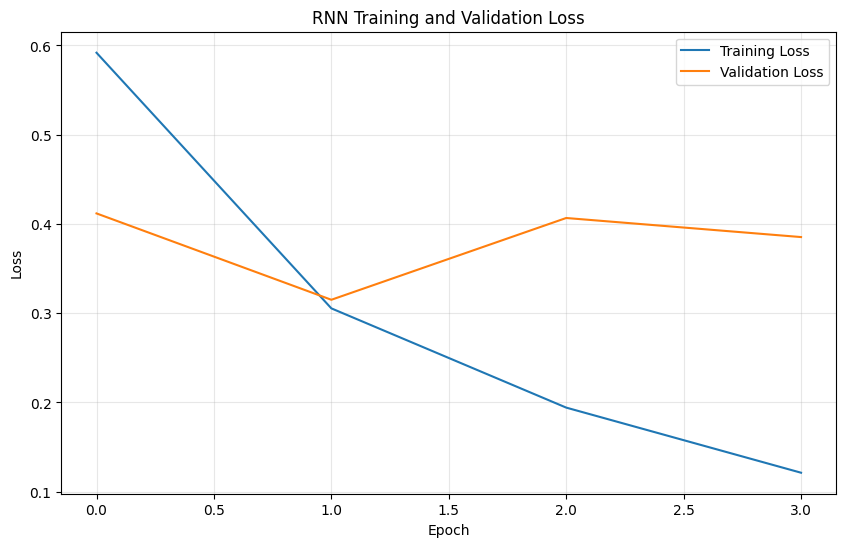

In [26]:
# ============================================================
# CELL 8: Plot Training Loss
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "RNN Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [27]:
# ============================================================
# CELL 9: Evaluate Model
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("RNN Test Results")
print("-" * 40)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

RNN Test Results
----------------------------------------
Test Loss: 0.3544
Test Accuracy: 0.8486
Test Accuracy: 84.86%


In [29]:
# ============================================================
# CELL 10: Generate Predictions
# ============================================================

probabilities = model.predict(
    X_test_padded,
    verbose=0
)

y_pred = (
    probabilities >= 0.5
).astype(int).flatten()

print("Predictions generated.")

print("Predicted labels:", y_pred[:20])
print("Actual labels   :", y_test[:20])

Predictions generated.
Predicted labels: [0 1 1 0 1 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0]
Actual labels   : [0 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0]


In [30]:
# ============================================================
# CELL 11: Classification Report
# ============================================================

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4
    )
)

Classification Report
              precision    recall  f1-score   support

    Negative     0.8409    0.8598    0.8503     12500
    Positive     0.8566    0.8374    0.8469     12500

    accuracy                         0.8486     25000
   macro avg     0.8488    0.8486    0.8486     25000
weighted avg     0.8488    0.8486    0.8486     25000



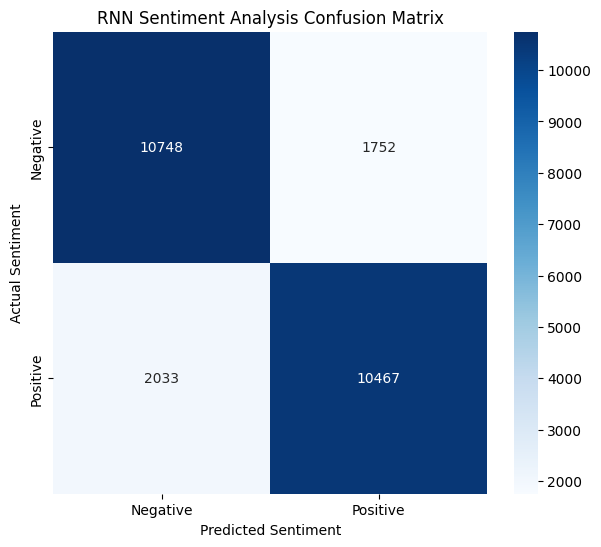

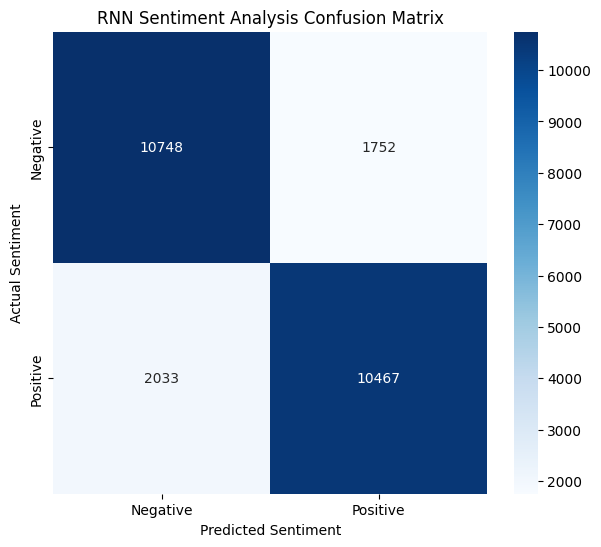

In [33]:
# ============================================================
# CELL 12: Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.title(
    "RNN Sentiment Analysis Confusion Matrix"
)

plt.show()

In [35]:
# ============================================================
# CELL 13: Predict Sentiment of New Reviews
# ============================================================

# Get the IMDB word dictionary
word_index = imdb.get_word_index()

def encode_review(text):

    words = text.lower().split()

    encoded = []

    for word in words:

        index = word_index.get(word, 0)

        # IMDB reserves indexes, so shift known words by 3
        if index != 0:
            index += 3

        encoded.append(index)

    return pad_sequences(
        [encoded],
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )


def predict_sentiment(text):

    encoded_review = encode_review(text)

    probability = model.predict(
        encoded_review,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", text)
    print(f"Positive probability: {probability:.4f}")
    print("Predicted sentiment:", sentiment)


predict_sentiment(
    "This movie was amazing and I really enjoyed it"
)

print()

predict_sentiment(
    "This movie was boring and I did not like it"
)

Review: This movie was amazing and I really enjoyed it
Positive probability: 0.6469
Predicted sentiment: Positive

Review: This movie was boring and I did not like it
Positive probability: 0.0947
Predicted sentiment: Negative
Review: This movie was amazing and I really enjoyed it
Positive probability: 0.6469
Predicted sentiment: Positive

Review: This movie was boring and I did not like it
Positive probability: 0.0947
Predicted sentiment: Negative


In [34]:
# ============================================================
# CELL 14: Final Results Summary
# ============================================================

final_results = pd.DataFrame({
    "Metric": [
        "Dataset",
        "Training Samples",
        "Testing Samples",
        "Vocabulary Size",
        "Maximum Sequence Length",
        "RNN Units",
        "Embedding Dimension",
        "Epochs",
        "Test Loss",
        "Test Accuracy"
    ],

    "Value": [
        "IMDB Movie Reviews",
        len(X_train),
        len(X_test),
        VOCAB_SIZE,
        MAX_LENGTH,
        64,
        EMBEDDING_DIM,
        5,
        f"{test_loss:.4f}",
        f"{test_accuracy * 100:.2f}%"
    ]
})

print(
    final_results.to_string(index=False)
)

                 Metric              Value
                Dataset IMDB Movie Reviews
       Training Samples              25000
        Testing Samples              25000
        Vocabulary Size              20000
Maximum Sequence Length                300
              RNN Units                 64
    Embedding Dimension                128
                 Epochs                  5
              Test Loss             0.3544
          Test Accuracy             84.86%
